In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('./data/raw/Life Expectancy Data.csv')
df.head()

,Country,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,percentage_expenditure,Hepatitis_B,Measles,...,Polio,Total_expenditure,Diphtheria,HIV_AIDS,GDP,Population,thinness _1_19_years,thinness_5_9_years,Income_composition_of_resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [3]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

# 정보 확인
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life_expectancy                  2928 non-null   float64
 4   Adult_Mortality                  2928 non-null   float64
 5   infant_deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage_expenditure           2938 non-null   float64
 8   Hepatitis_B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under_five_deaths                2938 non-null   int64  
 12  Polio               

In [4]:
# 컬럼명 앞뒤 공백 제거
df.columns = df.columns.str.strip()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life_expectancy                  2928 non-null   float64
 4   Adult_Mortality                  2928 non-null   float64
 5   infant_deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage_expenditure           2938 non-null   float64
 8   Hepatitis_B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2904 non-null   float64
 11  under_five_deaths                2938 non-null   int64  
 12  Polio               

In [5]:
print("결측치 개수:\n", df.isnull().sum())

결측치 개수:
 Country                              0
Year                                 0
Status                               0
Life_expectancy                     10
Adult_Mortality                     10
infant_deaths                        0
Alcohol                            194
percentage_expenditure               0
Hepatitis_B                        553
Measles                              0
BMI                                 34
under_five_deaths                    0
Polio                               19
Total_expenditure                  226
Diphtheria                          19
HIV_AIDS                             0
GDP                                448
Population                         652
thinness _1_19_years                34
thinness_5_9_years                  34
Income_composition_of_resources    167
Schooling                          163
dtype: int64


In [6]:
# 필요없는 값 제거
df = df.drop(['percentage_expenditure', 'Total_expenditure', 'Population', 'Income_composition_of_resources'], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               2938 non-null   object 
 1   Year                  2938 non-null   int64  
 2   Status                2938 non-null   object 
 3   Life_expectancy       2928 non-null   float64
 4   Adult_Mortality       2928 non-null   float64
 5   infant_deaths         2938 non-null   int64  
 6   Alcohol               2744 non-null   float64
 7   Hepatitis_B           2385 non-null   float64
 8   Measles               2938 non-null   int64  
 9   BMI                   2904 non-null   float64
 10  under_five_deaths     2938 non-null   int64  
 11  Polio                 2919 non-null   float64
 12  Diphtheria            2919 non-null   float64
 13  HIV_AIDS              2938 non-null   float64
 14  GDP                   2490 non-null   float64
 15  thinness _1_19_years 

# 한 나라의 모든 연도에서 column 4개 이상 비어있는 경우 제거

In [7]:
# 한 나라의 모든 연도가 비어있는 column이 4개 이상일 때
def check_empty_columns(group):
    # 특정 국가에서 모든 값이 NaN인 컬럼의 개수 계산
    empty_col_count = (group.isnull().sum() == len(group)).sum()
    return empty_col_count < 4

df = df.groupby('Country').filter(check_empty_columns)

print("결측치 개수:\n", df.isnull().sum())

결측치 개수:
 Country                   0
Year                      0
Status                    0
Life_expectancy           6
Adult_Mortality           6
infant_deaths             0
Alcohol                 178
Hepatitis_B             538
Measles                   0
BMI                      16
under_five_deaths         0
Polio                     8
Diphtheria                8
HIV_AIDS                  0
GDP                     436
thinness _1_19_years     16
thinness_5_9_years       16
Schooling               160
dtype: int64


In [8]:
df.shape

(2918, 18)

# BMI가 없는 나라 제거

In [9]:
df = df.groupby('Country').filter(lambda x: not x['BMI'].isnull().all())

# GDP 결측치 보강

In [10]:
gdp_df = pd.read_csv('./data/raw/GDP.csv', skiprows=4)

gdp_df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6767.559229,8244.045660,10056.261393,11507.217151,12187.536361,13233.990517,13892.605143,14700.959808,16055.287787,16548.717387,16620.954556,17750.009564,18828.087059,19216.197235,20681.023027,20740.132583,21307.248251,21949.485996,23700.631990,24171.837133,24845.658484,26736.308944,28171.909401,25134.771230,24093.140151,25712.384302,25119.665545,25813.571441,26129.839062,27458.220154,27441.550214,28440.041688,30082.158423,30645.890602,22759.807175,26749.329609,30975.998912,35718.753119,39498.594129,NaN
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,186.089204,186.909053,197.367547,225.400079,208.962717,226.836135,240.911794,243.773593,257.143823,281.578894,276.732924,294.814162,311.465053,389.729024,463.468775,479.078798,468.774522,518.358685,571.617317,634.448116,773.301205,777.627960,725.547511,732.345461,650.346841,554.221296,578.317452,664.791813,704.142066,728.243319,822.402999,864.174086,732.910915,709.323534,700.772126,766.522931,746.787335,767.399412,697.079415,670.424213,706.727261,625.827815,630.512328,815.432296,989.015464,1126.297323,1235.266608,1381.552597,1447.545754,1408.753467,1628.905248,1761.989261,1732.038021,1706.022744,1690.166792,1498.875240,1334.470500,1528.104224,1552.073722,1507.085600,1351.591669,1562.416175,1679.327622,1571.449189,1615.396356,NaN
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,174.930991,138.706822,178.954088,198.871116,221.763654,254.184249,274.218554,376.223152,381.733238,452.053705,560.621505,606.694676,651.417134,637.087099,625.054942,565.569730,522.082216,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895,NaN,NaN
3,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,121.936832,127.451040,133.823783,139.004980,148.545883,155.561897,162.107340,144.940804,146.186183,161.917968,218.672141,195.859987,230.068904,280.643967,368.294725,413.366170,480.447260,490.839577,523.781318,624.870707,763.011988,1328.793688,1164.188488,873.979407,738.545691,754.905547,582.885076,583.317520,563.117147,512.477735,593.024667,607.840414,567.153365,574.472939,580.008123,866.731606,1069.590240,1091.831529,1141.486651,523.797280,518.969226,532.972787,619.337335,697.481256,838.213392,999.770023,1234.641856,1405.880188,1666.520483,1453.495284,1662.633658,1844.054367,1941.118243,2131.606091,2221.350338,1860.727686,1630.039439,1574.230564,1720.140092,2216.385055,2030.861659,2112.794076,2138.473153,1841.855064,1411.337029,NaN
4,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,729.111965,657.982649,634.221467,636.832811,650.491094,772.468833,697.526602,770.101140,807.439628,907.747893,965.866840,881.919488,668.706017,449.727895,334.973590,404.294818,531.115367,521.702915,429.188127,392.725539,563.733796,533.586202,999.065856,1133.663320,1451.471179,2145.886211,2930.444286,3515.056790,4578.155265,3645.148466,4101.637156,5184.152691,5702.453063,5688.579162,5649.687625,3641.728939,2051.814621,2790.718869,2860.093648,2493.678844,1759.356199,2303.908127,3682.113151,2916.136633,2665.874448,NaN


In [11]:
gdp_null_info = df[df['GDP'].isnull()].groupby('Country')['Year'].count().reset_index()
gdp_null_info.columns = ['Country', 'Missing_Years_Count']

gdp_null_info

,Country,Missing_Years_Count
0,Bahamas,16
1,Bolivia (Plurinational State of),16
2,Congo,16
3,Czechia,16
4,Côte d'Ivoire,16
5,Democratic People's Republic of Korea,16
6,Democratic Republic of the Congo,16
7,Egypt,16
8,Eritrea,4
9,Gambia,16


In [12]:
null_gdp_countries = df[df['GDP'].isnull()]['Country'].unique()

print(len(null_gdp_countries))
print()
null_gdp_countries

33



array(['Bahamas', 'Bolivia (Plurinational State of)', "Côte d'Ivoire",
       'Congo', 'Czechia', "Democratic People's Republic of Korea",
       'Democratic Republic of the Congo', 'Egypt', 'Eritrea', 'Gambia',
       'Iran (Islamic Republic of)', 'Iraq', 'Kyrgyzstan',
       "Lao People's Democratic Republic", 'Libya',
       'Micronesia (Federated States of)', 'Papua New Guinea',
       'Republic of Korea', 'Republic of Moldova',
       'Saint Kitts and Nevis', 'Saint Lucia',
       'Saint Vincent and the Grenadines', 'Sao Tome and Principe',
       'Slovakia', 'Somalia', 'Syrian Arab Republic',
       'The former Yugoslav republic of Macedonia',
       'United Kingdom of Great Britain and Northern Ireland',
       'United Republic of Tanzania', 'United States of America',
       'Venezuela (Bolivarian Republic of)', 'Viet Nam', 'Yemen'],
      dtype=object)

In [13]:
search_results = []

for country in null_gdp_countries:
    # 해당 국가명이 포함된 월드뱅크의 국가명들을 검색 (대소문자 무시)
    match = gdp_df[gdp_df['Country Name'].str.contains(country.split('(')[0].strip(), case=False, na=False)]['Country Name'].unique()
    
    if len(match) > 0:
        search_results.append(f"기대수명 데이터: [{country}] -> 월드뱅크 후보: {list(match)}")
    else:
        search_results.append(f"기대수명 데이터: [{country}] -> 월드뱅크에서 찾을 수 없음")

# 결과 출력
for res in search_results:
    print(res)

기대수명 데이터: [Bahamas] -> 월드뱅크 후보: ['Bahamas, The']
기대수명 데이터: [Bolivia (Plurinational State of)] -> 월드뱅크 후보: ['Bolivia']
기대수명 데이터: [Côte d'Ivoire] -> 월드뱅크에서 찾을 수 없음
기대수명 데이터: [Congo] -> 월드뱅크 후보: ['Congo, Dem. Rep.', 'Congo, Rep.']
기대수명 데이터: [Czechia] -> 월드뱅크 후보: ['Czechia']
기대수명 데이터: [Democratic People's Republic of Korea] -> 월드뱅크에서 찾을 수 없음
기대수명 데이터: [Democratic Republic of the Congo] -> 월드뱅크에서 찾을 수 없음
기대수명 데이터: [Egypt] -> 월드뱅크 후보: ['Egypt, Arab Rep.']
기대수명 데이터: [Eritrea] -> 월드뱅크 후보: ['Eritrea']
기대수명 데이터: [Gambia] -> 월드뱅크 후보: ['Gambia, The']
기대수명 데이터: [Iran (Islamic Republic of)] -> 월드뱅크 후보: ['Iran, Islamic Rep.']
기대수명 데이터: [Iraq] -> 월드뱅크 후보: ['Iraq']
기대수명 데이터: [Kyrgyzstan] -> 월드뱅크에서 찾을 수 없음
기대수명 데이터: [Lao People's Democratic Republic] -> 월드뱅크에서 찾을 수 없음
기대수명 데이터: [Libya] -> 월드뱅크 후보: ['Libya']
기대수명 데이터: [Micronesia (Federated States of)] -> 월드뱅크 후보: ['Micronesia, Fed. Sts.']
기대수명 데이터: [Papua New Guinea] -> 월드뱅크 후보: ['Papua New Guinea']
기대수명 데이터: [Republic of Korea] -> 월드뱅크에서 찾을 수 없음
기대수명 데

In [14]:
#  병합을 위한 임시 매핑 사전 (df 이름 : 월드뱅크 이름)
# '찾을 수 없음'으로 나왔던 나라들도 월드뱅크 표준 명칭을 찾아 반영했습니다.
mapping_dict = {
    "Bahamas": "Bahamas, The",
    "Bolivia (Plurinational State of)": "Bolivia",
    "Côte d'Ivoire": "Cote d'Ivoire",
    "Congo": "Congo, Rep.", # 혹은 Congo, Dem. Rep. 확인 필요 (보통 Congo는 Rep.)
    "Democratic People's Republic of Korea": "Korea, Dem. People's Rep.",
    "Democratic Republic of the Congo": "Congo, Dem. Rep.",
    "Egypt": "Egypt, Arab Rep.",
    "Gambia": "Gambia, The",
    "Iran (Islamic Republic of)": "Iran, Islamic Rep.",
    "Kyrgyzstan": "Kyrgyz Republic",
    "Lao People's Democratic Republic": "Lao PDR",
    "Micronesia (Federated States of)": "Micronesia, Fed. Sts.",
    "Republic of Korea": "Korea, Rep.",
    "Republic of Moldova": "Moldova",
    "Saint Kitts and Nevis": "St. Kitts and Nevis",
    "Saint Lucia": "St. Lucia",
    "Saint Vincent and the Grenadines": "St. Vincent and the Grenadines",
    "Slovakia": "Slovak Republic",
    "Somalia": "Somalia, Fed. Rep.",
    "The former Yugoslav republic of Macedonia": "North Macedonia",
    "United Republic of Tanzania": "Tanzania",
    "United States of America": "United States",
    "Venezuela (Bolivarian Republic of)": "Venezuela, RB",
    "Yemen": "Yemen, Rep."
}

In [15]:
# 2. 월드뱅크 데이터를 세로(Long format)로 변환
# 2000년부터 2015년까지 데이터만 선택
gdp_long = gdp_df.melt(
    id_vars=['Country Name'], 
    value_vars=[str(year) for year in range(2000, 2016)],
    var_name='Year', 
    value_name='GDP_WB'
)

# 연도를 정수형으로 변환
gdp_long['Year'] = gdp_long['Year'].astype(int)

gdp_long.head()

,Country Name,Year,GDP_WB
0,Aruba,2000,20681.023027
1,Africa Eastern and Southern,2000,706.727261
2,Afghanistan,2000,174.930991
3,Africa Western and Central,2000,518.969226
4,Angola,2000,563.733796


In [16]:
# df에 임시 컬럼 생성
df['WB_Name'] = df['Country'].replace(mapping_dict)

# 병합 실행
df = pd.merge(
    df, 
    gdp_long, 
    left_on=['WB_Name', 'Year'], 
    right_on=['Country Name', 'Year'], 
    how='left'
)

# 기존 GDP 결측치에 월드뱅크 GDP 채워넣기
df['GDP'] = df['GDP'].fillna(df['GDP_WB'])

# 임시로 썼던 컬럼들 삭제
df = df.drop(columns=['WB_Name', 'Country Name', 'GDP_WB'])

# 그래도 비어있는 나라들
df[df['GDP'].isnull()]['Country'].unique()

array(["Democratic People's Republic of Korea", 'Eritrea',
       'United Kingdom of Great Britain and Northern Ireland'],
      dtype=object)

In [17]:
# 보강 후에도 여전히 데이터가 전혀 없는 나라 확인 및 제거
# 특정 나라의 gdp가 모두 nan인지 확인
gdp_missing_countries = df.groupby('Country')['GDP'].transform(lambda x: x.isnull().all())
df = df[~gdp_missing_countries]

df[df['GDP'].isnull()]

,Country,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,Hepatitis_B,Measles,BMI,under_five_deaths,Polio,Diphtheria,HIV_AIDS,GDP,thinness _1_19_years,thinness_5_9_years,Schooling
849,Eritrea,2015,Developing,64.7,255.0,5,NaN,95.0,198,18.6,7,95.0,95.0,0.4,NaN,8.4,8.2,5.0
850,Eritrea,2014,Developing,64.4,261.0,5,0.01,94.0,127,18.0,8,94.0,94.0,0.4,NaN,8.5,8.3,5.0
851,Eritrea,2013,Developing,64.0,266.0,6,0.01,94.0,45,17.5,8,94.0,94.0,0.5,NaN,8.6,8.4,5.0
852,Eritrea,2012,Developing,63.6,274.0,6,0.01,94.0,194,17.0,8,94.0,94.0,0.6,NaN,8.7,8.6,5.0


In [18]:
df[df['Country'] == 'Eritrea']

,Country,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,Hepatitis_B,Measles,BMI,under_five_deaths,Polio,Diphtheria,HIV_AIDS,GDP,thinness _1_19_years,thinness_5_9_years,Schooling
849,Eritrea,2015,Developing,64.7,255.0,5,NaN,95.0,198,18.6,7,95.0,95.0,0.4,NaN,8.4,8.2,5.0
850,Eritrea,2014,Developing,64.4,261.0,5,0.01,94.0,127,18.0,8,94.0,94.0,0.4,NaN,8.5,8.3,5.0
851,Eritrea,2013,Developing,64.0,266.0,6,0.01,94.0,45,17.5,8,94.0,94.0,0.5,NaN,8.6,8.4,5.0
852,Eritrea,2012,Developing,63.6,274.0,6,0.01,94.0,194,17.0,8,94.0,94.0,0.6,NaN,8.7,8.6,5.0
853,Eritrea,2011,Developing,62.9,286.0,6,0.62,96.0,48,16.5,8,96.0,96.0,0.7,582.775532,8.8,8.7,5.0
854,Eritrea,2010,Developing,62.1,298.0,6,0.61,9.0,51,16.0,9,9.0,9.0,0.9,482.149940,8.9,8.8,5.1
855,Eritrea,2009,Developing,61.4,311.0,6,0.63,92.0,82,15.5,9,92.0,92.0,1.0,43.754450,9.0,8.9,5.2
856,Eritrea,2008,Developing,67.0,322.0,6,0.49,94.0,0,15.1,9,94.0,94.0,1.1,326.825642,9.1,9.1,5.2
857,Eritrea,2007,Developing,62.0,329.0,6,1.23,91.0,55,14.7,9,91.0,91.0,1.3,317.329434,9.2,9.2,5.3
858,Eritrea,2006,Developing,59.7,336.0,7,0.97,94.0,128,14.3,9,94.0,94.0,1.4,297.828588,9.3,9.3,5.3


In [19]:
# Eritrea 걍 지워버릴게요
df = df[df['Country'] != 'Eritrea']
df[df['GDP'].isnull()]

,Country,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,Hepatitis_B,Measles,BMI,under_five_deaths,Polio,Diphtheria,HIV_AIDS,GDP,thinness _1_19_years,thinness_5_9_years,Schooling


In [20]:
df['Country'].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia',
       'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh',
       'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan',
       'Bolivia (Plurinational State of)', 'Bosnia and Herzegovina',
       'Botswana', 'Brazil', 'Brunei Darussalam', 'Bulgaria',
       'Burkina Faso', 'Burundi', "Côte d'Ivoire", 'Cabo Verde',
       'Cambodia', 'Cameroon', 'Canada', 'Central African Republic',
       'Chad', 'Chile', 'China', 'Colombia', 'Comoros', 'Congo',
       'Costa Rica', 'Croatia', 'Cuba', 'Cyprus', 'Czechia',
       'Democratic Republic of the Congo', 'Denmark', 'Djibouti',
       'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Estonia', 'Ethiopia', 'Fiji',
       'Finland', 'France', 'Gabon', 'Gambia', 'Georgia', 'Germany',
       'Ghana', 'Greece', 'Grenada', 'Guatemala', 'Guinea',
       'Guinea-Bissa

# 알코올 결측치

In [21]:
print("결측치 개수:\n", df.isnull().sum())
print()
print(df[df['Alcohol'].isnull()]['Country'].unique())

결측치 개수:
 Country                   0
Year                      0
Status                    0
Life_expectancy           6
Adult_Mortality           6
infant_deaths             0
Alcohol                 175
Hepatitis_B             512
Measles                   0
BMI                       0
under_five_deaths         0
Polio                     8
Diphtheria                8
HIV_AIDS                  0
GDP                       0
thinness _1_19_years      0
thinness_5_9_years        0
Schooling               128
dtype: int64

['Algeria' 'Angola' 'Antigua and Barbuda' 'Argentina' 'Armenia'
 'Australia' 'Austria' 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh'
 'Barbados' 'Belarus' 'Belgium' 'Belize' 'Benin' 'Bhutan'
 'Bolivia (Plurinational State of)' 'Bosnia and Herzegovina' 'Botswana'
 'Brazil' 'Brunei Darussalam' 'Bulgaria' 'Burkina Faso' 'Burundi'
 "Côte d'Ivoire" 'Cabo Verde' 'Cambodia' 'Cameroon' 'Canada'
 'Central African Republic' 'Chad' 'Chile' 'China' 'Colombia' 'Comoros'
 'Congo' 'C

In [22]:
alcohol_null_info = df[df['Alcohol'].isnull()].groupby('Country')['Year'].count().reset_index()
alcohol_null_info.columns = ['Country', 'Missing_Years_Count']

alcohol_null_info

,Country,Missing_Years_Count
0,Algeria,1
1,Angola,1
2,Antigua and Barbuda,1
3,Argentina,1
4,Armenia,1
5,Australia,1
6,Austria,1
7,Azerbaijan,1
8,Bahamas,1
9,Bahrain,1


In [23]:
# 몬테 뭐시기 배고 전부 1이라 그냥 나라내에서 평균 내고 싶은데
df.loc[df['Country'] == 'Montenegro', ['Year', 'Alcohol']]

,Year,Alcohol
1730,2015,NaN
1731,2014,0.01
1732,2013,0.01
1733,2012,0.01
1734,2011,6.56
1735,2010,6.56
1736,2009,6.45
1737,2008,6.17
1738,2007,4.98
1739,2006,5.38


In [24]:
# 일단 alcohol.csv에 잇는지 확인
# 근데 걍 보간하고 싶네
alcohol_df = pd.read_csv('./data/raw/alcohol.csv')

alcohol_total_df = alcohol_df[alcohol_df['Dim1'] == 'All types'][['Location', 'Period', 'FactValueNumeric']]

alcohol_total_df.head()

,Location,Period,FactValueNumeric
3,Afghanistan,2022,0.000
13,Bangladesh,2022,0.002
81,Iran (Islamic Republic of),2022,0.000
94,Kuwait,2022,0.040
105,Libya,2022,0.000


In [25]:
alcohol_nulls = df[df['Alcohol'].isnull()][['Country', 'Year']]

alcohol_nulls.head()

,Country,Year
32,Algeria,2015
48,Angola,2015
64,Antigua and Barbuda,2015
80,Argentina,2015
96,Armenia,2015


In [26]:
check_match = pd.merge(alcohol_nulls, alcohol_total_df, 
                       left_on=['Country', 'Year'], 
                       right_on=['Location', 'Period'], 
                       how='inner')

# csv에서 가져올 수 있는 값들
check_match.head()

,Country,Year,Location,Period,FactValueNumeric
0,Algeria,2015,Algeria,2015,0.47
1,Angola,2015,Angola,2015,6.31
2,Antigua and Barbuda,2015,Antigua and Barbuda,2015,8.89
3,Argentina,2015,Argentina,2015,8.37
4,Armenia,2015,Armenia,2015,4.06


In [27]:
alcohol_data = alcohol_total_df.copy()
alcohol_data.columns = ['WHO_Country', 'WHO_Year', 'WHO_Value']

df = pd.merge(df, alcohol_data, 
              left_on=['Country', 'Year'], 
              right_on=['WHO_Country', 'WHO_Year'], 
              how='left')

df['Alcohol'] = df['Alcohol'].fillna(df['WHO_Value'])

df = df.drop(columns=['WHO_Country', 'WHO_Year', 'WHO_Value'])

In [28]:
alcohol_null_info = df[df['Alcohol'].isnull()].groupby('Country')['Year'].count().reset_index()
alcohol_null_info.columns = ['Country', 'Missing_Years_Count']

alcohol_null_info

,Country,Missing_Years_Count
0,Côte d'Ivoire,1
1,Montenegro,1
2,Netherlands,1
3,Palau,1
4,Saudi Arabia,1
5,Swaziland,1
6,The former Yugoslav republic of Macedonia,1
7,Turkey,1


In [29]:
# who 데이터에서 못 채운 나머지는 보간
df['Alcohol'] = df.groupby('Country')['Alcohol'].transform(lambda x: x.interpolate(limit_direction='both'))

df[df['Alcohol'].isnull()]

,Country,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,Hepatitis_B,Measles,BMI,under_five_deaths,Polio,Diphtheria,HIV_AIDS,GDP,thinness _1_19_years,thinness_5_9_years,Schooling
1923,Palau,2013,Developing,NaN,NaN,0,NaN,99.0,0,83.3,0,99.0,99.0,0.1,1932.12237,0.1,0.1,14.2


In [30]:
df[df['Country'] == 'Palau']

,Country,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,Hepatitis_B,Measles,BMI,under_five_deaths,Polio,Diphtheria,HIV_AIDS,GDP,thinness _1_19_years,thinness_5_9_years,Schooling
1923,Palau,2013,Developing,NaN,NaN,0,NaN,99.0,0,83.3,0,99.0,99.0,0.1,1932.12237,0.1,0.1,14.2


In [31]:
# Palau도 연도가 하나 밖에 없어서 걍 지워버릴게요
df = df[df['Country'] != 'Palau']
df[df['Alcohol'].isnull()]

,Country,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,Hepatitis_B,Measles,BMI,under_five_deaths,Polio,Diphtheria,HIV_AIDS,GDP,thinness _1_19_years,thinness_5_9_years,Schooling


##### 중간 점검

In [32]:
print("결측치 개수:\n", df.isnull().sum())

결측치 개수:
 Country                   0
Year                      0
Status                    0
Life_expectancy           5
Adult_Mortality           5
infant_deaths             0
Alcohol                   0
Hepatitis_B             512
Measles                   0
BMI                       0
under_five_deaths         0
Polio                     8
Diphtheria                8
HIV_AIDS                  0
GDP                       0
thinness _1_19_years      0
thinness_5_9_years        0
Schooling               128
dtype: int64


# B형 간염

In [33]:
alcohol_null_info = df[df['Hepatitis_B'].isnull()].groupby('Country')['Year'].count().reset_index()
alcohol_null_info.columns = ['Country', 'Missing_Years_Count']

alcohol_null_info

,Country,Missing_Years_Count
0,Algeria,4
1,Angola,7
2,Antigua and Barbuda,1
3,Argentina,2
4,Australia,1
5,Azerbaijan,2
6,Bahamas,1
7,Bangladesh,3
8,Barbados,1
9,Benin,2


In [34]:
B_df = pd.read_csv('./data/raw/Hepatitis_B.csv')
B_df.head()

,IndicatorCode,Indicator,ValueType,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,IsLatestYear,Dim1 type,Dim1,Dim1ValueCode,Dim2 type,Dim2,Dim2ValueCode,Dim3 type,Dim3,Dim3ValueCode,DataSourceDimValueCode,DataSource,FactValueNumericPrefix,FactValueNumeric,FactValueUoM,FactValueNumericLowPrefix,FactValueNumericLow,FactValueNumericHighPrefix,FactValueNumericHigh,Value,FactValueTranslationID,FactComments,Language,DateModified
0,WHS4_117,Hepatitis B (HepB3) immunization coverage among 1-year-olds (%),numeric,EUR,Europe,Country,DNK,Denmark,Year,2024,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,EN,2025-07-13T15:00:00.000Z
1,WHS4_117,Hepatitis B (HepB3) immunization coverage among 1-year-olds (%),numeric,EUR,Europe,Country,FIN,Finland,Year,2024,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,EN,2025-07-13T15:00:00.000Z
2,WHS4_117,Hepatitis B (HepB3) immunization coverage among 1-year-olds (%),numeric,EUR,Europe,Country,HUN,Hungary,Year,2024,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,EN,2025-07-13T15:00:00.000Z
3,WHS4_117,Hepatitis B (HepB3) immunization coverage among 1-year-olds (%),numeric,EUR,Europe,Country,ISL,Iceland,Year,2024,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,EN,2025-07-13T15:00:00.000Z
4,WHS4_117,Hepatitis B (HepB3) immunization coverage among 1-year-olds (%),numeric,EMR,Eastern Mediterranean,Country,SDN,Sudan,Year,2024,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39,NaN,NaN,NaN,NaN,NaN,39,NaN,NaN,EN,2025-07-13T15:00:00.000Z


# 개발도상국-선진국 인코딩

In [35]:
from sklearn.preprocessing import LabelEncoder

# 인코더 생성
le = LabelEncoder()

# Status 컬럼 인코딩 (B_df는 사용 중인 데이터프레임 이름에 맞게 수정하세요)
df['Status_encoded'] = le.fit_transform(df['Status'])

# 결과 확인
print(f"인코딩된 클래스 확인: {le.classes_}") # ['Developed', 'Developing'] 순서면 0, 1로 매핑됨
display(df[['Status', 'Status_encoded']].head())

인코딩된 클래스 확인: ['Developed' 'Developing']


,Status,Status_encoded
0,Developing,1
1,Developing,1
2,Developing,1
3,Developing,1
4,Developing,1


# region 변수 생성

In [36]:
!pip install pycountry_convert #파이썬에 대륙을 변환해주는 패키지가 따로 있음

ERROR: Invalid requirement: '#파이썬에': Expected package name at the start of dependency specifier
    #파이썬에
    ^


In [37]:
import pycountry_convert as pc #패키지 실행

def country_to_continent(country_name):
    try:
        # 국가 이름을 국가 코드로 변환
        country_alpha2 = pc.country_name_to_country_alpha2(country_name)
        # 국가 코드를 대륙 코드로 변환
        continent_code = pc.country_alpha2_to_continent_code(country_alpha2)
        # 대륙 코드를 전체 이름으로 변환
        continent_name = {
            'AF': 'Africa', 'AS': 'Asia', 'EU': 'Europe', 
            'NA': 'North America', 'SA': 'South America', 'OC': 'Oceania', 'AN': 'Antarctica'
        }
        return continent_name.get(continent_code)
    except:
        return "Others" # 매핑이 안 되는 경우 (예: 국가명 오타 등)

df['Region'] = df['Country'].apply(country_to_continent) #region 변수 추가

display(df[['Country', 'Region']].head())

,Country,Region
0,Afghanistan,Asia
1,Afghanistan,Asia
2,Afghanistan,Asia
3,Afghanistan,Asia
4,Afghanistan,Asia


In [38]:
from sklearn.preprocessing import LabelEncoder

le_region = LabelEncoder()
df['Region_encoded'] = le_region.fit_transform(df['Region'])

print(f"새로 정의된 지역들: {le_region.classes_}")

# Africa - 0, Asia - 1, Europe - 2, North America - 3, Oceania - 4, Others - 5

새로 정의된 지역들: ['Africa' 'Asia' 'Europe' 'North America' 'Oceania' 'Others'
 'South America']


C:\Users\yunu2\AppData\Local\Temp\ipykernel_34800\3721147062.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Region', y='Life_expectancy', data=df, palette='Spectral')


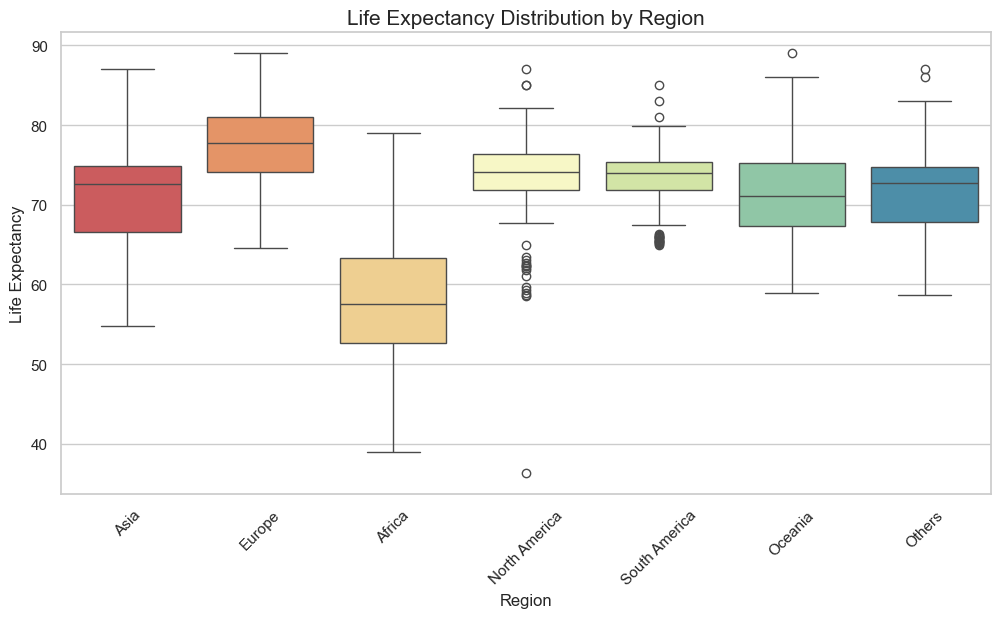

In [39]:
# 시각화 스타일 설정
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Region별 Life expectancy 분포 시각화
sns.boxplot(x='Region', y='Life_expectancy', data=df, palette='Spectral')

plt.title('Life Expectancy Distribution by Region', fontsize=15)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Life Expectancy', fontsize=12)
plt.xticks(rotation=45) # 지역 이름이 겹치면 회전
plt.show()

C:\Users\yunu2\AppData\Local\Temp\ipykernel_34800\2413986523.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Region', y='Adult_Mortality', data=df, palette='Spectral')


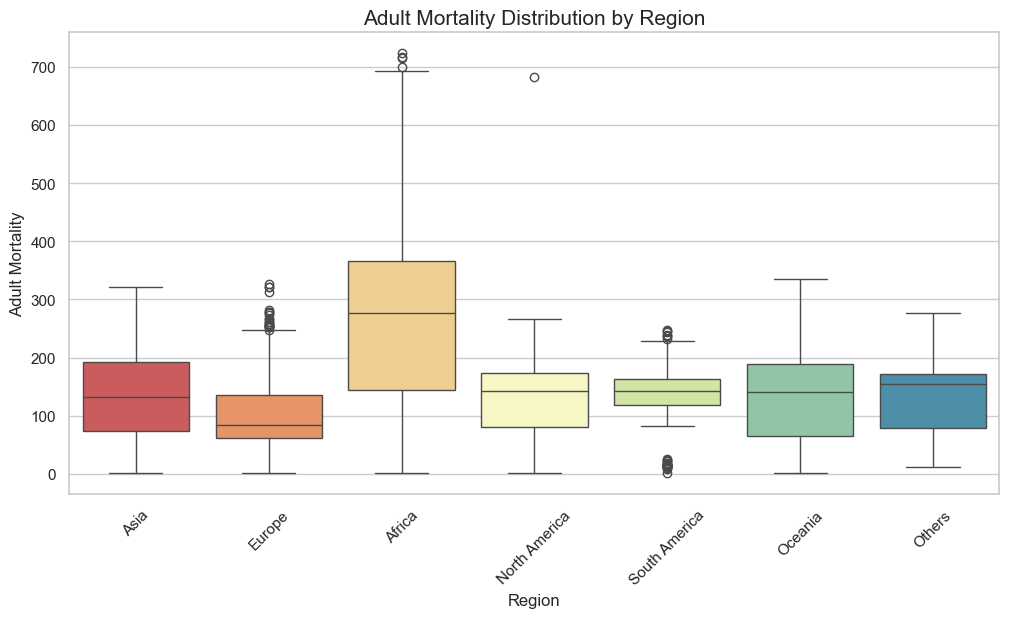

In [40]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

sns.boxplot(x='Region', y='Adult_Mortality', data=df, palette='Spectral')

plt.title('Adult Mortality Distribution by Region', fontsize=15)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Adult Mortality', fontsize=12)
plt.xticks(rotation=45) # 지역 이름이 겹치면 회전
plt.show()

In [41]:
df

,Country,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,Hepatitis_B,Measles,BMI,under_five_deaths,Polio,Diphtheria,HIV_AIDS,GDP,thinness _1_19_years,thinness_5_9_years,Schooling,Status_encoded,Region,Region_encoded
0,Afghanistan,2015,Developing,65.0,263.0,62,0.010,65.0,1154,19.1,83,6.0,65.0,0.1,584.259210,17.2,17.3,10.1,1,Asia,1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.010,62.0,492,18.6,86,58.0,62.0,0.1,612.696514,17.5,17.5,10.0,1,Asia,1
2,Afghanistan,2013,Developing,59.9,268.0,66,0.010,64.0,430,18.1,89,62.0,64.0,0.1,631.744976,17.7,17.7,9.9,1,Asia,1
3,Afghanistan,2012,Developing,59.5,272.0,69,0.010,67.0,2787,17.6,93,67.0,67.0,0.1,669.959000,17.9,18.0,9.8,1,Asia,1
4,Afghanistan,2011,Developing,59.2,275.0,71,0.010,68.0,3013,17.2,97,68.0,68.0,0.1,63.537231,18.2,18.2,9.5,1,Asia,1
5,Afghanistan,2010,Developing,58.8,279.0,74,0.010,66.0,1989,16.7,102,66.0,66.0,0.1,553.328940,18.4,18.4,9.2,1,Asia,1
6,Afghanistan,2009,Developing,58.6,281.0,77,0.010,63.0,2861,16.2,106,63.0,63.0,0.1,445.893298,18.6,18.7,8.9,1,Asia,1
7,Afghanistan,2008,Developing,58.1,287.0,80,0.030,64.0,1599,15.7,110,64.0,64.0,0.1,373.361116,18.8,18.9,8.7,1,Asia,1
8,Afghanistan,2007,Developing,57.5,295.0,82,0.020,63.0,1141,15.2,113,63.0,63.0,0.1,369.835796,19.0,19.1,8.4,1,Asia,1
9,Afghanistan,2006,Developing,57.3,295.0,84,0.030,64.0,1990,14.7,116,58.0,58.0,0.1,272.563770,19.2,19.3,8.1,1,Asia,1


C:\Users\yunu2\AppData\Local\Temp\ipykernel_34800\1124665928.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Region', y=col, data=df, ax=axes[i], palette='Set3')
C:\Users\yunu2\AppData\Local\Temp\ipykernel_34800\1124665928.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Region', y=col, data=df, ax=axes[i], palette='Set3')
C:\Users\yunu2\AppData\Local\Temp\ipykernel_34800\1124665928.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Region', y=col, data=df, ax=axes[i], palette='Set3')
C:\Users\yunu2\AppData\Local\Temp\ipy

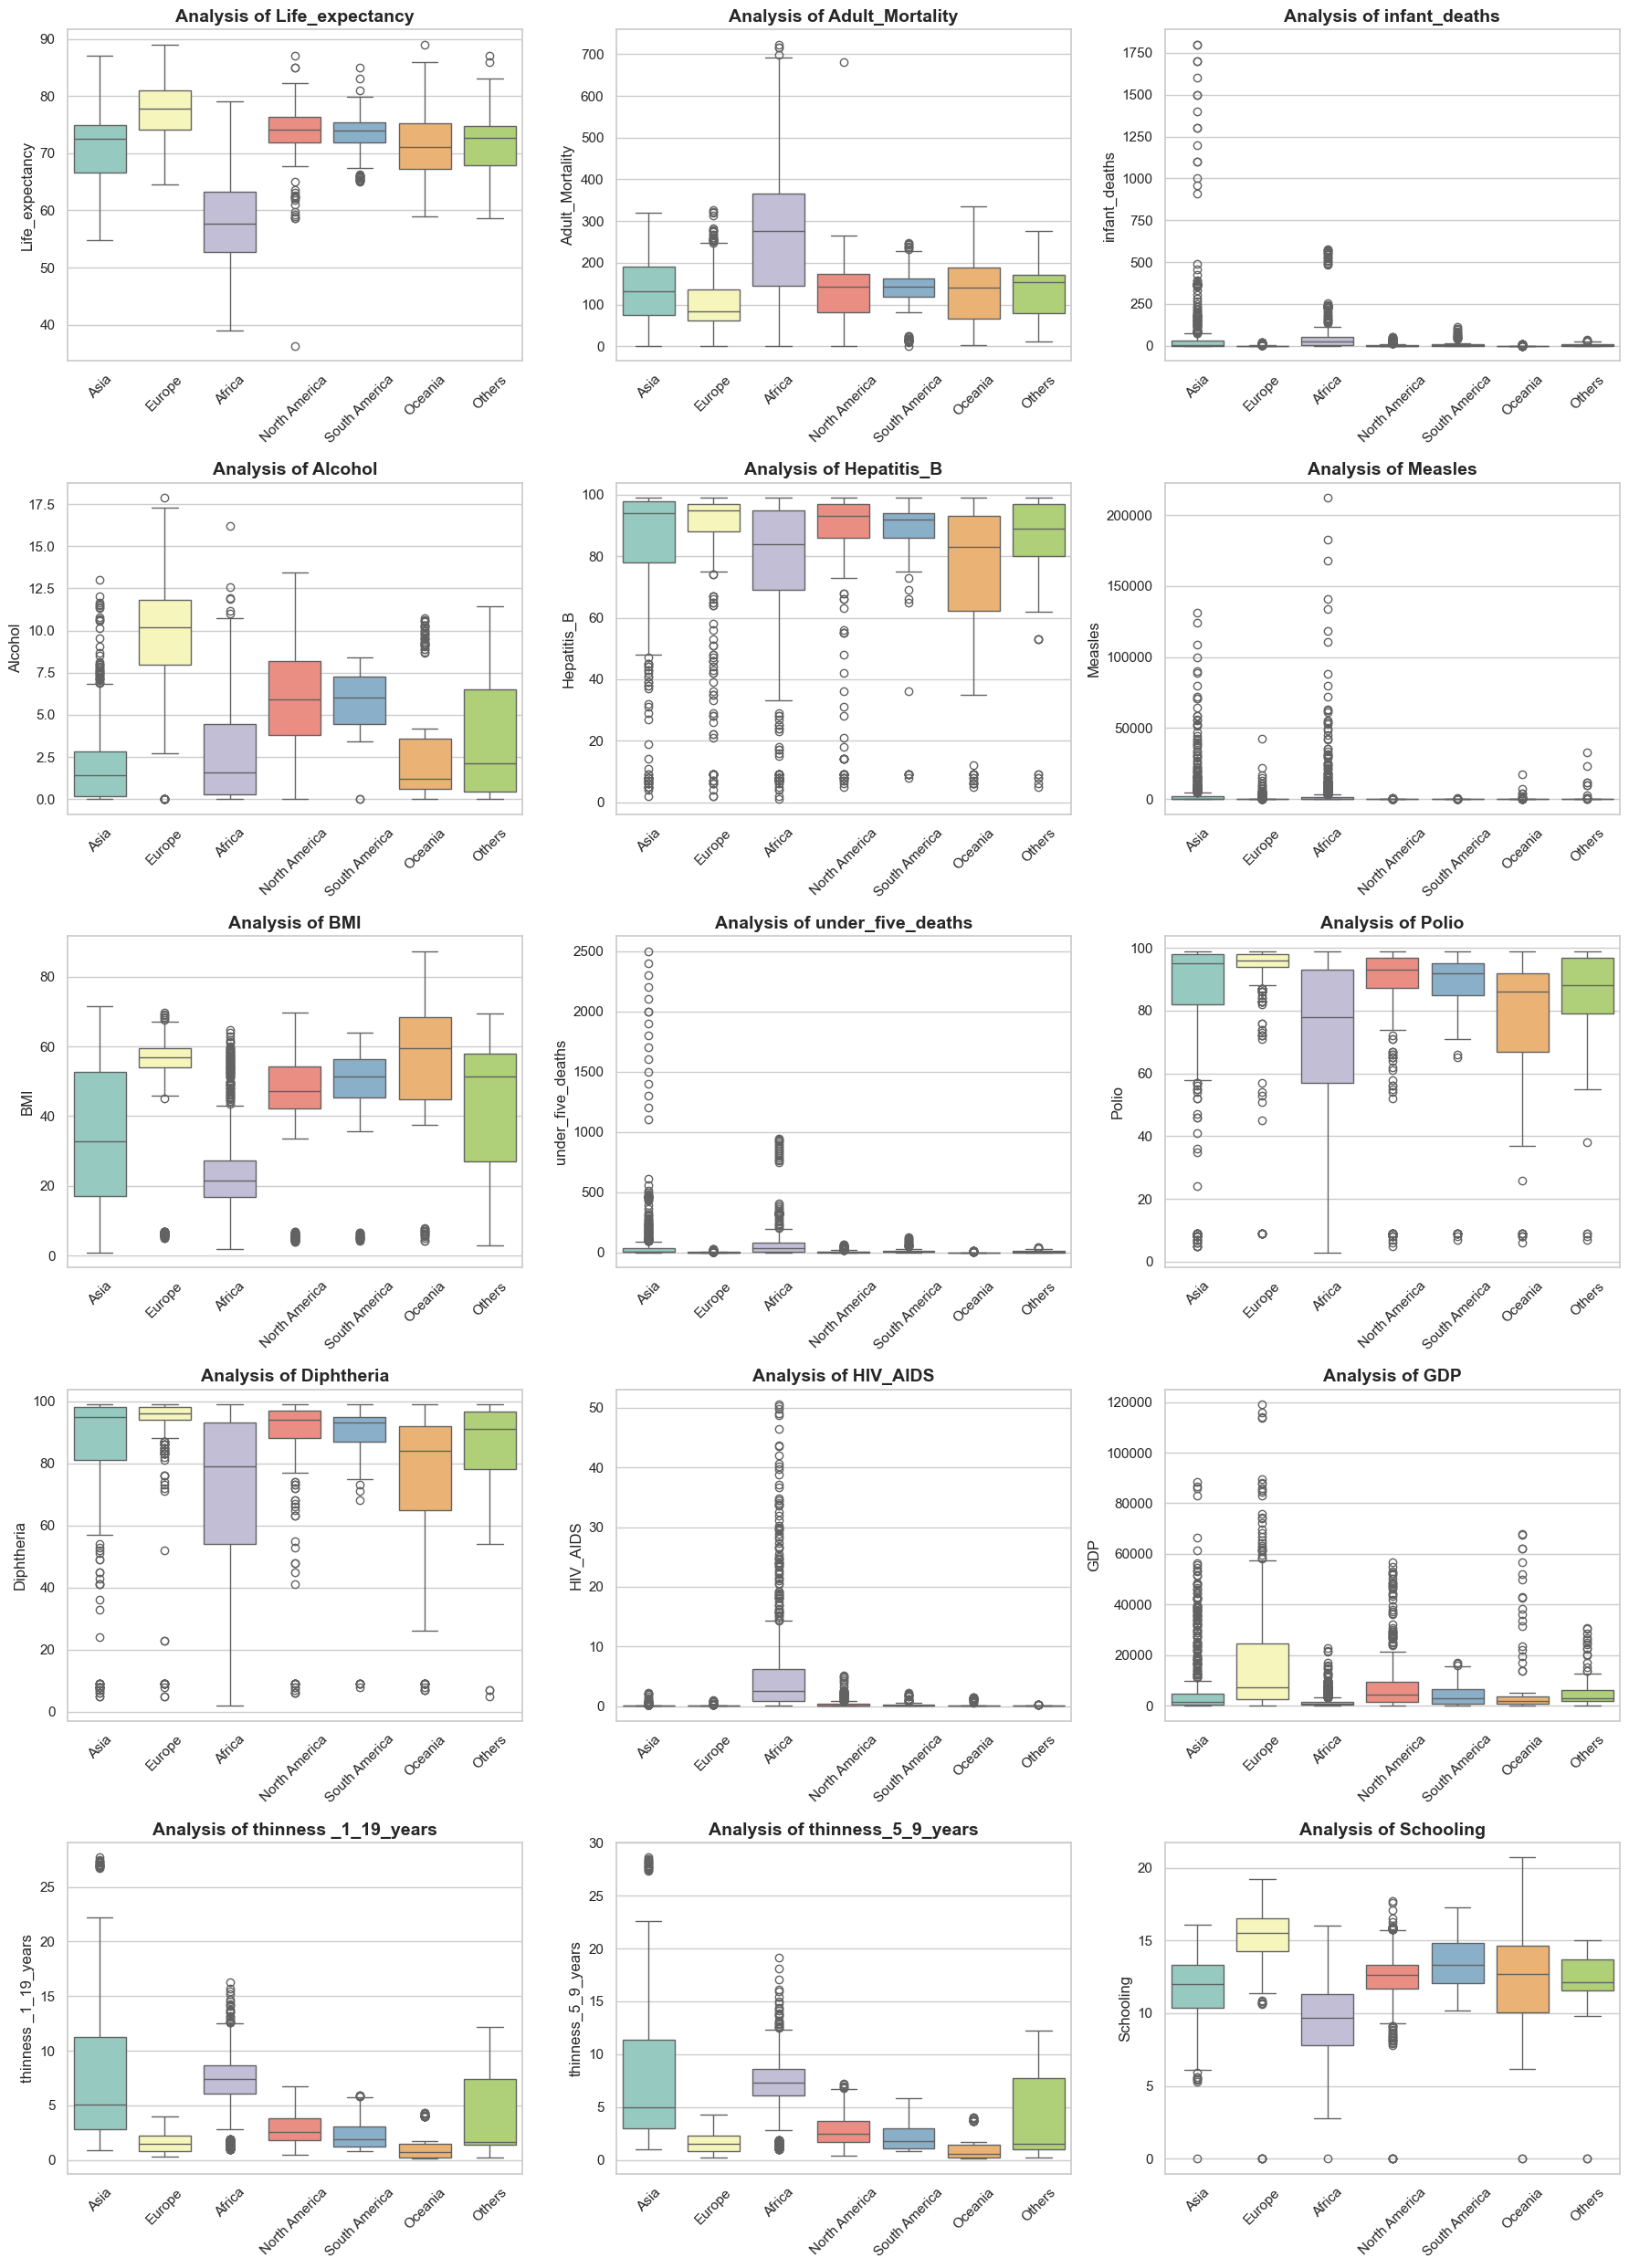

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 시각화에서 제외할 컬럼 리스트 정의
# 인코딩된 변수들과 분석에 의미 없는 변수들을 한꺼번에 넣으세요.
exclude_cols = ['Year', 'Status_encoded', 'Region_encoded']

# 2. 수치형 컬럼 중 exclude_cols에 포함되지 않은 것만 필터링
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
plot_cols = [col for col in numeric_cols if col not in exclude_cols]

# 3. 그래프 배치 설정
num_cols = 3
num_rows = (len(plot_cols) + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, num_rows * 5))
axes = axes.flatten()

# 4. 반복문으로 그리기
for i, col in enumerate(plot_cols):
    sns.boxplot(x='Region', y=col, data=df, ax=axes[i], palette='Set3')
    axes[i].set_title(f'Analysis of {col}', fontsize=14, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')

# 빈 서브플롯 제거
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2853 entries, 0 to 2853
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               2853 non-null   object 
 1   Year                  2853 non-null   int64  
 2   Status                2853 non-null   object 
 3   Life_expectancy       2848 non-null   float64
 4   Adult_Mortality       2848 non-null   float64
 5   infant_deaths         2853 non-null   int64  
 6   Alcohol               2853 non-null   float64
 7   Hepatitis_B           2341 non-null   float64
 8   Measles               2853 non-null   int64  
 9   BMI                   2853 non-null   float64
 10  under_five_deaths     2853 non-null   int64  
 11  Polio                 2845 non-null   float64
 12  Diphtheria            2845 non-null   float64
 13  HIV_AIDS              2853 non-null   float64
 14  GDP                   2853 non-null   float64
 15  thinness _1_19_years  2853